# Lecture 11: RNN for Next-Token Prediction and Text Generation
## Beginner PyTorch Notebook

This notebook continues directly from Lectures 09 and 10 with the same six-sentence corpus.

- No document or sentiment classification
- No custom Python `class`
- No custom `def` function
- PyTorch `nn.Embedding`, `nn.RNN`, and `nn.Linear`
- Fixed `window = 3` and `horizon = 1`
- Full-batch training because the corpus is very small

The goal is to understand the data flow, hidden states, and autoregressive generation. The result is a classroom demonstration, not a benchmark.


## Practice Problem

**Scenario:** Use the same new four-sentence corpus as the Lecture 09
and Lecture 10 practice problems:

```python
corpus_p = [
    "Noah walks a dog in the park.",
    "Mia walks a cat in the park.",
    "Emma feeds a bird in the garden.",
    "Liam feeds a fish in the garden.",
]
```

Using the **same method** as this lecture, do the following:

1. Tokenize the corpus and build a vocabulary with the four special
   tokens, then encode every sentence with `<BOS>` and `<EOS>`.
2. Build fixed-window next-token pairs with `WINDOW=3`, `HORIZON=1`.
3. Build a SimpleRNN from three PyTorch layers:
   `nn.Embedding(EMBEDDING_DIM=16)`, `nn.RNN(HIDDEN_DIM=32)`, and
   `nn.Linear`.
4. Train for 300 epochs with `Adam(lr=0.03)`, `F.cross_entropy`, and
   gradient clipping (`max_norm=1.0`), the same way as this lecture.
5. Report the training loss and accuracy at epochs 1, 50, 100, 200, 300.
6. Check the model's top-3 next-token predictions for the prompt
   `["<BOS>", "noah", "walks"]`.


### Solution

Vocabulary size: 20
Number of training pairs: 28
Epoch   1 | loss = 2.9845 | training accuracy = 7.1%
Epoch  50 | loss = 0.0005 | training accuracy = 100.0%
Epoch 100 | loss = 0.0002 | training accuracy = 100.0%
Epoch 200 | loss = 0.0001 | training accuracy = 100.0%
Epoch 300 | loss = 0.0001 | training accuracy = 100.0%

Prompt: ['<BOS>', 'noah', 'walks']
  a          1.0000
  dog        0.0000
  garden     0.0000


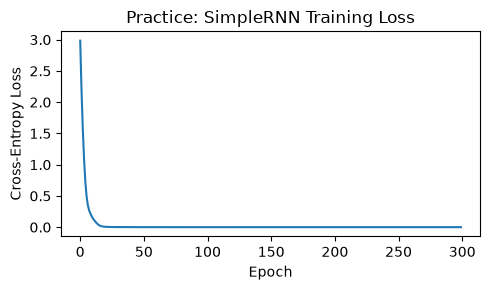

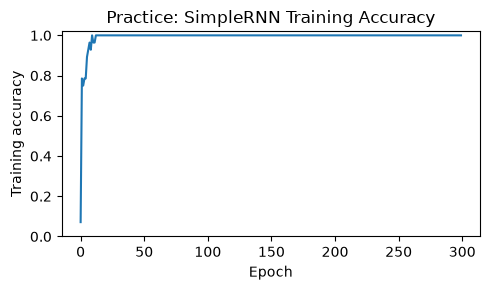

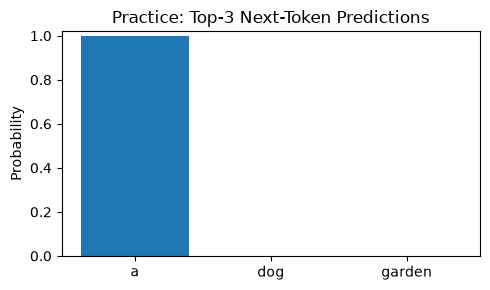

In [1]:
import matplotlib.pyplot as plt

import re
import torch
import torch.nn as nn
import torch.nn.functional as F
SEED = 42
torch.manual_seed(SEED)
torch.set_num_threads(1)


# ----- New corpus -----
corpus_p = [
    "Noah walks a dog in the park.",
    "Mia walks a cat in the park.",
    "Emma feeds a bird in the garden.",
    "Liam feeds a fish in the garden.",
]

# ----- Tokenize and build the vocabulary -----
token_pattern_p = r"[a-z]+|[.,!?;]"
tokenized_corpus_p = []
for sentence in corpus_p:
    tokens = re.findall(token_pattern_p, sentence.lower())
    tokenized_corpus_p.append(tokens)

special_tokens_p = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]
PAD_ID_p, UNK_ID_p, BOS_ID_p, EOS_ID_p = 0, 1, 2, 3

token_counts_p = {}
for sentence_tokens in tokenized_corpus_p:
    for token in sentence_tokens:
        token_counts_p[token] = token_counts_p.get(token, 0) + 1

ordered_tokens_p = sorted(token_counts_p.keys())
ordered_tokens_p.sort(key=token_counts_p.get, reverse=True)
vocabulary_p = special_tokens_p + ordered_tokens_p

token_to_id_p, id_to_token_p = {}, {}
for token_id, token in enumerate(vocabulary_p):
    token_to_id_p[token] = token_id
    id_to_token_p[token_id] = token

print("Vocabulary size:", len(vocabulary_p))

# ----- Encode with <BOS>/<EOS> -----
encoded_corpus_p = []
for sentence_tokens in tokenized_corpus_p:
    token_ids = [BOS_ID_p]
    for token in sentence_tokens:
        token_ids.append(token_to_id_p.get(token, UNK_ID_p))
    token_ids.append(EOS_ID_p)
    encoded_corpus_p.append(token_ids)

# ----- Build fixed-window next-token pairs -----
WINDOW_p = 3
HORIZON_p = 1
input_windows_p, target_ids_p = [], []

for token_ids in encoded_corpus_p:
    number_of_pairs = len(token_ids) - WINDOW_p - HORIZON_p + 1
    for start in range(number_of_pairs):
        stop = start + WINDOW_p
        target_position = stop + HORIZON_p - 1
        input_windows_p.append(token_ids[start:stop])
        target_ids_p.append(token_ids[target_position])

X_p = torch.tensor(input_windows_p, dtype=torch.long)
y_p = torch.tensor(target_ids_p, dtype=torch.long)
print("Number of training pairs:", len(X_p))

# ----- Build the SimpleRNN -----
VOCAB_SIZE_p = len(vocabulary_p)
EMBEDDING_DIM_p = 16
HIDDEN_DIM_p = 32

torch.manual_seed(SEED)
embedding_p = nn.Embedding(num_embeddings=VOCAB_SIZE_p, embedding_dim=EMBEDDING_DIM_p, padding_idx=PAD_ID_p)
rnn_p = nn.RNN(input_size=EMBEDDING_DIM_p, hidden_size=HIDDEN_DIM_p, batch_first=True)
output_layer_p = nn.Linear(HIDDEN_DIM_p, VOCAB_SIZE_p)

# ----- Train with full-batch cross-entropy -----
parameters_p = (
    list(embedding_p.parameters())
    + list(rnn_p.parameters())
    + list(output_layer_p.parameters())
)

optimizer_p = torch.optim.Adam(parameters_p, lr=0.03)
EPOCHS_p = 300
loss_history_p = []
accuracy_history_p = []

for epoch in range(1, EPOCHS_p + 1):
    optimizer_p.zero_grad()
    embedded = embedding_p(X_p)
    rnn_outputs, final_hidden = rnn_p(embedded)
    logits = output_layer_p(rnn_outputs[:, -1, :])

    loss = F.cross_entropy(logits, y_p)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(parameters_p, max_norm=1.0)
    optimizer_p.step()

    predictions = logits.argmax(dim=1)
    accuracy = (predictions == y_p).float().mean().item()
    loss_history_p.append(loss.item())
    accuracy_history_p.append(accuracy)

    if epoch in [1, 50, 100, 200, 300]:
        print(
            f"Epoch {epoch:3d} | "
            f"loss = {loss.item():.4f} | "
            f"training accuracy = {accuracy * 100:.1f}%"
        )

# ----- Check next-token probabilities for a prompt -----
embedding_p.eval()
rnn_p.eval()
output_layer_p.eval()

prompt_tokens_p = ["<BOS>", "noah", "walks"]

with torch.no_grad():
    prompt_ids_p = torch.tensor(
        [[token_to_id_p.get(token, UNK_ID_p) for token in prompt_tokens_p]],
        dtype=torch.long,
    )
    prompt_vectors = embedding_p(prompt_ids_p)
    prompt_outputs, prompt_hidden = rnn_p(prompt_vectors)
    prompt_logits = output_layer_p(prompt_outputs[:, -1, :])
    prompt_probabilities = torch.softmax(prompt_logits, dim=1)[0]
    top_probabilities, top_ids = torch.topk(prompt_probabilities, k=3)

print()
print("Prompt:", prompt_tokens_p)
for probability, token_id in zip(top_probabilities, top_ids):
    print(f"  {id_to_token_p[int(token_id)]:10s} {float(probability):.4f}")


# ----- Visualization 1: training loss -----
plt.figure(figsize=(5, 3))
plt.plot(loss_history_p)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Practice: SimpleRNN Training Loss")
plt.grid(False)
plt.tight_layout()
plt.show()

# ----- Visualization 2: training accuracy -----
plt.figure(figsize=(5, 3))
plt.plot(accuracy_history_p)
plt.xlabel("Epoch")
plt.ylabel("Training accuracy")
plt.ylim(0, 1.02)
plt.title("Practice: SimpleRNN Training Accuracy")
plt.grid(False)
plt.tight_layout()
plt.show()

# ----- Visualization 3: top-3 next-token probabilities -----
top_tokens_p = [id_to_token_p[int(token_id)] for token_id in top_ids]
top_values_p = [float(p) for p in top_probabilities]

plt.figure(figsize=(5, 3))
plt.bar(top_tokens_p, top_values_p)
plt.ylim(0, 1.02)
plt.ylabel("Probability")
plt.title("Practice: Top-3 Next-Token Predictions")
plt.grid(False)
plt.tight_layout()
plt.show()
